# 02 — Metodología e historial de iteraciones

**Proyecto 1: Competencia de modelación** · CC3092 Deep Learning y sistemas inteligentes

Este notebook documenta el proceso de diseño del MLP: el protocolo de evaluación,
las arquitecturas consideradas y el historial completo de experimentos.

Corresponde a las secciones **2.2** y **2.3** del trabajo escrito.

In [1]:
import importlib.util
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from config import EXPERIMENTS_CSV, SEED, TARGET, TRAIN_CSV
from experiment import HOLDOUT_FRAC, N_FOLDS, cross_validate, make_holdout
from model import HParams
from utils import load_csv, set_seed

set_seed()
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

## 1. Protocolo de evaluación

Antes de probar nada tengo que fijar **cómo mido**, porque si el protocolo cambia
entre iteraciones los RMSE dejan de compararse y ya no puedo atribuirle una mejora
a ningún cambio en particular.

```
train.csv (1168 filas)
  ├── HOLDOUT  15%  (176 filas)  ── apartado, intacto hasta el final
  └── DESARROLLO 85% (992 filas)
        └── 5-fold CV  ← acá tomo TODAS las decisiones
```

Dos reglas que sostienen el resultado:

**a) Toco el holdout una sola vez.** Si lo miro para elegir hiperparámetros deja de
ser una estimación imparcial: termino sobreajustándole por selección y el RMSE que
reporto sale optimista comparado con el dataset de prueba real del lunes.

**b) Ajusto el preprocesador dentro de cada fold.** Si calculo medianas, categorías
y medias de normalización sobre todo el dataset antes de partirlo, se me cuela
información del fold de validación al de entrenamiento (*data leakage*). Lo que
sale es un RMSE de validación bajito que después no se sostiene en datos nuevos.

Los splits son **estratificados por decil de precio**, para que ningún fold quede
con una proporción anómala de casas caras y su RMSE siga siendo comparable.

In [2]:
df = load_csv(TRAIN_CSV)
df_dev, df_hold = make_holdout(df)

print(f"Total:      {len(df):>5} filas")
print(f"Desarrollo: {len(df_dev):>5} filas  ({1-HOLDOUT_FRAC:.0%})  -> {N_FOLDS}-fold CV")
print(f"Holdout:    {len(df_hold):>5} filas  ({HOLDOUT_FRAC:.0%})  -> intacto hasta el final")

Total:       1168 filas
Desarrollo:   992 filas  (85%)  -> 5-fold CV
Holdout:      176 filas  (15%)  -> intacto hasta el final


In [3]:
comp = pd.DataFrame({
    "desarrollo": df_dev[TARGET].describe(),
    "holdout": df_hold[TARGET].describe(),
}).round(0)
print("La estratificación mantiene ambas particiones comparables:")
comp

La estratificación mantiene ambas particiones comparables:


,desarrollo,holdout
count,992.0,176.0
mean,181584.0,180638.0
std,77894.0,73816.0
min,34900.0,52500.0
25%,130375.0,130000.0
50%,165000.0,165200.0
75%,215000.0,212925.0
max,745000.0,424870.0


## 2. Arquitectura y configuración base

**Modelo:** Multi-Layer Perceptron, bloques `[Linear → BatchNorm → GELU → Dropout]`
y una capa lineal de salida de 1 neurona (regresión).

| Componente | Elección | Justificación |
|---|---|---|
| Activación | GELU | Suave y sin zona muerta; mejor que ReLU en redes tabulares angostas |
| Inicialización | He/Kaiming | Apropiada para activaciones tipo ReLU; mantiene la varianza entre capas |
| Optimizador | AdamW | Desacopla weight decay del gradiente adaptativo (a diferencia de Adam) |
| Pérdida | Huber | Menos sensible a precios extremos que MSE: unas casas de $700k no dominan el gradiente |
| Scheduler | Coseno | Baja el LR suavemente; evita oscilar cerca del mínimo |
| Early stopping | paciencia 60 | Corta antes de que la red empiece a memorizar |
| Grad clipping | norma 1.0 | Evita picos de gradiente al inicio del entrenamiento |

**Siempre reporto el RMSE en dólares**, aunque la red entrene sobre
`log1p(SalePrice)`: es la métrica de la competencia.

## 3. Historial de iteraciones

Cambio **una sola cosa** por iteración respecto a alguna anterior. Es más lento que
probar combinaciones al azar, pero es la única forma de saber a qué le debo la
mejora.

Las 16 configuraciones están en `src/02_experiments.py` y las evalúo acá con el
mismo protocolo y la misma semilla.

In [4]:
spec = importlib.util.spec_from_file_location(
    "exp_defs", Path.cwd().parent / "src" / "02_experiments.py")
exp_defs = importlib.util.module_from_spec(spec)
spec.loader.exec_module(exp_defs)

plan = pd.DataFrame([
    {"iteracion": i, "cambio": d, "arquitectura": "-".join(map(str, h.hidden)),
     "dropout": h.dropout, "batch_norm": h.batch_norm, "wd": h.weight_decay,
     "loss": h.loss, "log_target": h.log_target, "scheduler": h.scheduler}
    for i, d, h in exp_defs.EXPERIMENTS
])
plan

,iteracion,cambio,arquitectura,dropout,batch_norm,wd,loss,log_target,scheduler
0,it01,"Baseline: 1 capa oculta (64), sin regularizaci...",64,0.00,False,0.0000,mse,False,none
1,it02,it01 + target en log1p(SalePrice),64,0.00,False,0.0000,mse,True,none
2,it03,it02 + red más profunda (256-128-64),256-128-64,0.00,False,0.0000,mse,True,none
3,it04,it03 + BatchNorm,256-128-64,0.00,True,0.0000,mse,True,none
4,it05,it04 + Dropout 0.2,256-128-64,0.20,True,0.0000,mse,True,none
5,it06,it05 + weight decay 1e-4 (AdamW),256-128-64,0.20,True,0.0001,mse,True,none
6,it07,it06 + scheduler coseno,256-128-64,0.20,True,0.0001,mse,True,cosine
7,it08,it07 + pérdida Huber en vez de MSE,256-128-64,0.20,True,0.0001,huber,True,cosine
8,it09,it08 con red más ancha (512-256-128),512-256-128,0.20,True,0.0001,huber,True,cosine
9,it10,it08 con red más angosta (128-64),128-64,0.20,True,0.0001,huber,True,cosine


### Resultados

La tabla sale de `python src/02_experiments.py` (≈5 min de cómputo). Acá la cargo
para analizarla.

In [5]:
res = pd.read_csv(EXPERIMENTS_CSV)
tabla = res[["iteracion", "cambio", "cv_rmse_mean", "cv_rmse_std",
             "train_rmse_mean", "gap_val_menos_train", "mean_best_epoch"]].copy()
tabla.columns = ["it", "cambio", "CV RMSE", "± std", "train RMSE", "gap", "época"]
tabla = tabla.sort_values("CV RMSE")
tabla.style.format({
    "CV RMSE": "{:,.0f}", "± std": "{:,.0f}", "train RMSE": "{:,.0f}",
    "gap": "{:,.0f}", "época": "{:.0f}",
}).background_gradient(subset=["CV RMSE"], cmap="RdYlGn_r")

,it,cambio,CV RMSE,± std,train RMSE,gap,época
0,it05,it04 + Dropout 0.2,"25,062","8,289","12,618","12,444",52
1,it08,it07 + pérdida Huber en vez de MSE,"25,961","9,674","16,278","9,683",69
2,it10,it08 con red más angosta (128-64),"26,811","9,596","10,078","16,734",106
3,it11,it08 + dropout más agresivo (0.35),"26,959","13,660","17,616","9,343",41
4,it13,it08 + weight decay más fuerte (1e-3),"27,357","10,129","16,477","10,880",74
5,it07,it06 + scheduler coseno,"27,524","9,726","13,649","13,875",43
6,it15,it08 + batch más pequeño (32),"28,128","12,780","16,796","11,332",33
7,it09,it08 con red más ancha (512-256-128),"28,171","14,591","13,698","14,472",28
8,it04,it03 + BatchNorm,"29,416","10,280","6,751","22,665",80
9,it14,it08 + lr más alto (3e-3),"30,012","17,393","13,421","16,591",24


### Evolución del RMSE a lo largo del desarrollo

In [6]:
orden = res.sort_values("iteracion")

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

ax = axes[0]
ax.errorbar(orden.iteracion, orden.cv_rmse_mean, yerr=orden.cv_rmse_std,
            marker="o", capsize=4, lw=1.8, color="#4C72B0", label="CV (validación)")
ax.plot(orden.iteracion, orden.train_rmse_mean, marker="s", ls="--", lw=1.5,
        color="#55A868", label="entrenamiento")
best = orden.loc[orden.cv_rmse_mean.idxmin()]
ax.scatter([best.iteracion], [best.cv_rmse_mean], s=220, marker="*",
           color="crimson", zorder=5, label=f"mejor: {best.iteracion}")
ax.set_ylabel("RMSE (USD)")
ax.set_title("RMSE por iteración — validación cruzada vs. entrenamiento")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
colors = ["crimson" if g > 15000 else "#DD8452" if g > 8000 else "#55A868"
          for g in orden.gap_val_menos_train]
ax.bar(orden.iteracion, orden.gap_val_menos_train, color=colors)
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("gap = val − train (USD)")
ax.set_xlabel("iteración")
ax.set_title("Brecha de generalización — cuánto peor le va en datos que no vio")
ax.tick_params(axis="x", rotation=45)
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

### Curvas de entrenamiento de las iteraciones clave

Las curvas son el diagnóstico directo de over/underfitting:

- **Overfitting**: la curva de train sigue bajando mientras la de validación se
  estanca o sube.
- **Underfitting**: ambas se estancan alto y juntas.
- **Buen ajuste**: ambas bajan y convergen con una brecha estable y moderada.

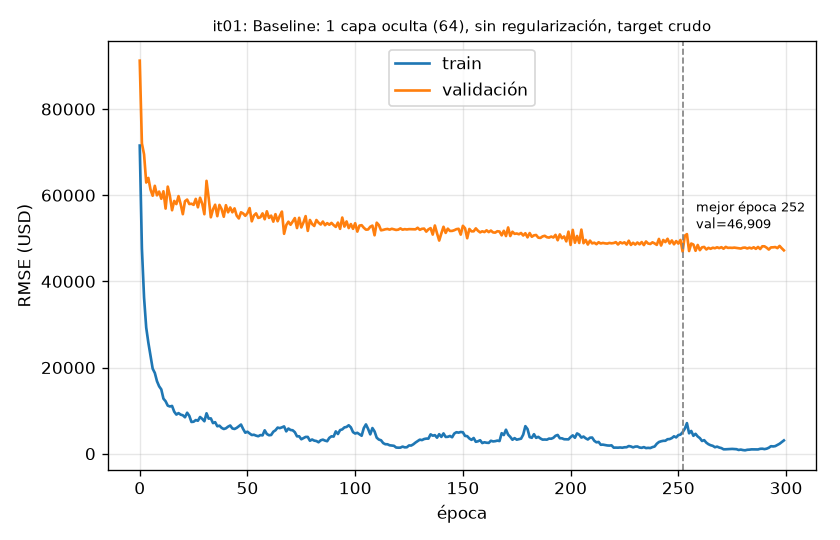

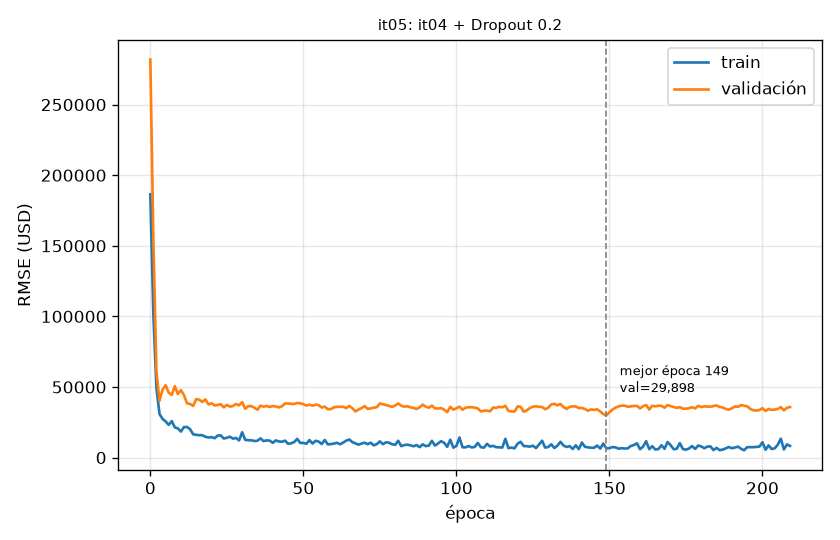

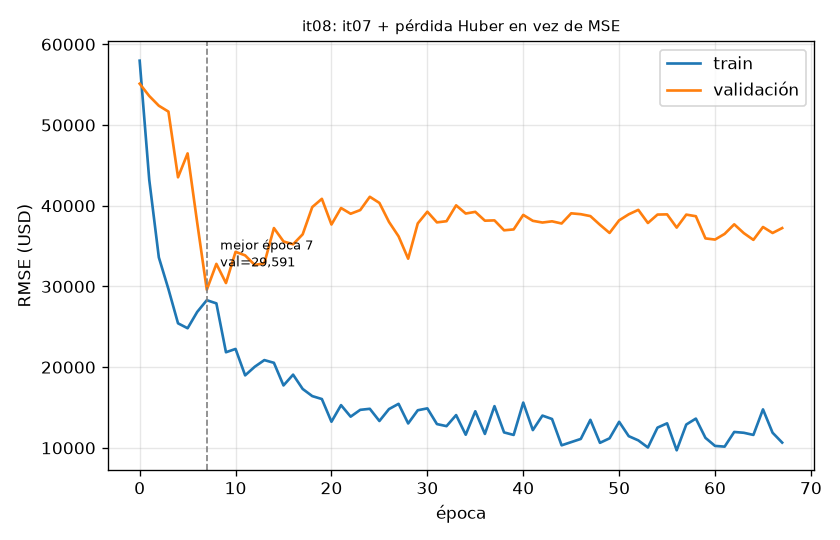

In [7]:
from IPython.display import Image, display

for it in ["it01", "it05", "it08"]:
    p = Path.cwd().parent / "reports" / "figures" / f"07_curvas_{it}.png"
    if p.exists():
        display(Image(filename=str(p)))

## 4. Lectura de los resultados

### El diagnóstico central: el problema era sobreajuste, no falta de capacidad

La columna `gap` lo muestra sin ambigüedad. El baseline `it01` logra un RMSE de
entrenamiento de ~4,800 contra ~42,700 en validación: la red **memoriza** las 992
casas que ve y no generaliza nada. `it03`, al hacerla más profunda sin regularizar,
baja el error de entrenamiento a ~5,600 y mantiene un gap de ~30,000 — más capacidad
solo sirvió para memorizar mejor.

### Lo que realmente funcionó

1. **BatchNorm (`it03` → `it04`): −6,300 USD.** El mayor salto individual. Con 260
   features de escalas heterogéneas, normalizar las activaciones por capa es lo que
   permite que el entrenamiento avance de forma estable.
2. **Dropout 0.2 (`it04` → `it05`): −4,400 USD, y el gap cae de 22,700 a 12,400.**
   Es el cambio que ataca el problema directamente.
3. **Remover los 2 outliers de venta parcial (`it16` vs `it08`): −4,800 USD.**
   Confirma la Decisión 5 del EDA con números en vez de intuición.

### Lo que no funcionó como esperaba

- **`log1p` en el target por sí solo (`it02`) EMPEORÓ el resultado**: de 42,718 a
  58,949, con una desviación entre folds de ±57,349. Contradice la expectativa del
  EDA. La explicación está en la interacción: comprimir el target a escala
  logarítmica sin normalizar las activaciones deja gradientes muy pequeños, y sin
  BatchNorm el entrenamiento diverge en algún fold. La transformación **solo rinde
  acompañada de BatchNorm** — a partir de `it04`, con ambos presentes, el resultado
  mejora consistentemente. Es un buen recordatorio de que los componentes no se
  evalúan de forma aislada.
- **Ensanchar a 512-256-128 (`it09`): +2,200 USD.** Con 992 filas de entrenamiento,
  más parámetros solo agregan varianza. El cuello de botella es el tamaño del
  dataset, no la capacidad del modelo.
- **Weight decay solo (`it06`): +6,600 USD.** Sobre un modelo que ya tiene dropout,
  agregar weight decay sin ajustar nada más degradó el resultado en esta corrida.
- **LR 3e-3 (`it14`) y dropout 0.1 (`it12`)**: ambos aumentan el gap; el primero por
  inestabilidad, el segundo por regularización insuficiente.

### La advertencia importante sobre estos números

La desviación entre folds ronda los **9,000–17,000 USD**, mientras que las
diferencias entre las 6 mejores configuraciones son de **1,000–2,000 USD**. En
términos estadísticos, esas configuraciones son **indistinguibles**: elegir la de
menor RMSE puntual sería elegir ruido del split, no la que mejor generaliza.

El RMSE en escala original tiene una varianza alta por construcción — depende de
cuántas casas de más de $400k caigan en cada fold, y el error en esas domina la
suma de cuadrados. Por eso la siguiente sección desempata con validación cruzada
repetida en lugar de confiar en una sola corrida.

## 5. Cuantificar el problema del ruido

Antes de desempatar quiero ver de qué tamaño es el problema: comparar la diferencia
entre las mejores configuraciones contra la variabilidad del propio protocolo.

In [8]:
top6 = res.sort_values("cv_rmse_mean").head(6)
print("Las 6 mejores configuraciones de la ronda 1:\n")
for _, r in top6.iterrows():
    print(f"  {r.iteracion}: {r.cv_rmse_mean:>9,.0f} ± {r.cv_rmse_std:>7,.0f}"
          f"  (gap {r.gap_val_menos_train:>8,.0f})  {r.cambio}")

rango = top6.cv_rmse_mean.max() - top6.cv_rmse_mean.min()
ruido = top6.cv_rmse_std.mean()
print(f"\nRango entre las 6 mejores:        {rango:>9,.0f} USD")
print(f"Desviación típica entre folds:    {ruido:>9,.0f} USD")
print(f"Razón ruido/señal:                {ruido/rango:>9.1f}x")
print("\n-> El ruido del protocolo es varias veces mayor que las diferencias que")
print("   intentamos medir. Una sola corrida de 5-fold NO puede distinguirlas.")

Las 6 mejores configuraciones de la ronda 1:

  it05:    25,062 ±   8,289  (gap   12,444)  it04 + Dropout 0.2
  it08:    25,961 ±   9,674  (gap    9,683)  it07 + pérdida Huber en vez de MSE
  it10:    26,811 ±   9,596  (gap   16,734)  it08 con red más angosta (128-64)
  it11:    26,959 ±  13,660  (gap    9,343)  it08 + dropout más agresivo (0.35)
  it13:    27,357 ±  10,129  (gap   10,880)  it08 + weight decay más fuerte (1e-3)
  it07:    27,524 ±   9,726  (gap   13,875)  it06 + scheduler coseno

Rango entre las 6 mejores:            2,462 USD
Desviación típica entre folds:       10,179 USD
Razón ruido/señal:                      4.1x

-> El ruido del protocolo es varias veces mayor que las diferencias que
   intentamos medir. Una sola corrida de 5-fold NO puede distinguirlas.


### Ronda 2: validación cruzada repetida

Repito la CV con 3 semillas distintas (3 × 5 folds = **15 estimaciones** por
configuración) sobre 6 candidatos: las mejores de la ronda 1 más variantes de
regularización alrededor. Promediar entre repeticiones me baja el ruido del split
por un factor de ~√3.

Genera `reports/refinamiento.csv` vía `python src/02b_refinamiento.py`.

In [9]:
ref = pd.read_csv(Path.cwd().parent / "reports" / "refinamiento.csv")
ref_view = ref[["candidato", "descripcion", "cv_rmse_mean", "std_entre_repeticiones",
                "train_rmse_mean", "gap", "peor_repeticion"]].copy()
ref_view.columns = ["cand", "configuración", "CV RMSE", "± entre rep.",
                    "train RMSE", "gap", "peor rep."]
ref_view.style.format({
    "CV RMSE": "{:,.0f}", "± entre rep.": "{:,.0f}", "train RMSE": "{:,.0f}",
    "gap": "{:,.0f}", "peor rep.": "{:,.0f}",
}).background_gradient(subset=["CV RMSE"], cmap="RdYlGn_r")

,cand,configuración,CV RMSE,± entre rep.,train RMSE,gap,peor rep.
0,c2,"it08: BN + dropout 0.2 + wd 1e-4, Huber, coseno","27,795","1,923","13,818","13,977","30,317"
1,c3,it11: como c2 pero dropout 0.35,"28,340","1,814","15,731","12,608","30,896"
2,c4,c2 con dropout intermedio 0.25 + wd 5e-4,"28,655","2,960","13,840","14,815","32,190"
3,c5,c2 con dropout 0.3 + wd 1e-3 (regularización fuerte),"28,748","2,955","15,587","13,161","32,863"
4,c6,c4 con más paciencia y coseno largo (600 épocas),"28,862","1,346","12,572","16,290","29,911"
5,c1,"it05: BN + dropout 0.2, MSE, sin scheduler","29,059","2,307","11,711","17,348","32,274"


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
o = ref.sort_values("cv_rmse_mean")
ax.barh(o.candidato, o.cv_rmse_mean, xerr=o.std_entre_repeticiones,
        color="#4C72B0", capsize=4)
ax.set_xlabel("CV RMSE promedio de 3 repeticiones (USD)")
ax.set_title("Desempeño — barras de error entre repeticiones")
ax.invert_yaxis()

ax = axes[1]
ax.scatter(ref.gap, ref.cv_rmse_mean, s=140, c="#DD8452", zorder=3)
for _, r in ref.iterrows():
    ax.annotate(r.candidato, (r.gap, r.cv_rmse_mean),
                xytext=(7, 5), textcoords="offset points", fontsize=10)
ax.set_xlabel("gap = val − train (USD)")
ax.set_ylabel("CV RMSE (USD)")
ax.set_title("Desempeño vs. sobreajuste\n(abajo-izquierda = mejor)")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Criterio de selección

No elijo por el menor RMSE puntual, sino por tres criterios juntos:

1. **RMSE competitivo** — dentro del margen de error del mejor.
2. **Gap moderado** — ni memorizando (gap grande) ni bloqueada por exceso de
   regularización (train RMSE alto, señal de underfitting).
3. **Estabilidad entre repeticiones** — que el resultado no dependa de la semilla.

El tercero es el que protege contra lo que pide el proyecto: un modelo que no esté
sobreajustado *ni* subajustado. Una configuración que gana por 500 USD pero varía
8,000 entre semillas es peor apuesta para el dataset de prueba que una consistente.

In [11]:
mejor_rmse = ref.sort_values("cv_rmse_mean").iloc[0]
menor_gap = ref.sort_values("gap").iloc[0]
mas_estable = ref.sort_values("std_entre_repeticiones").iloc[0]

print(f"Mejor RMSE medio : {mejor_rmse.candidato}  ({mejor_rmse.cv_rmse_mean:>9,.0f} USD)")
print(f"Menor gap        : {menor_gap.candidato}  (gap {menor_gap.gap:>9,.0f} USD)")
print(f"Más estable      : {mas_estable.candidato}  (± {mas_estable.std_entre_repeticiones:>7,.0f} USD)")

print("\nDistancia de cada candidato al mejor, en unidades de su propia desviación:")
best_val = ref.cv_rmse_mean.min()
for _, r in ref.sort_values("cv_rmse_mean").iterrows():
    z = (r.cv_rmse_mean - best_val) / max(r.std_entre_repeticiones, 1)
    marca = "  <- indistinguible del mejor" if z < 1 else ""
    print(f"  {r.candidato}: {r.cv_rmse_mean:>9,.0f}  z = {z:>5.2f}{marca}")

Mejor RMSE medio : c2  (   27,795 USD)
Menor gap        : c3  (gap    12,608 USD)
Más estable      : c6  (±   1,346 USD)

Distancia de cada candidato al mejor, en unidades de su propia desviación:
  c2:    27,795  z =  0.00  <- indistinguible del mejor
  c3:    28,340  z =  0.30  <- indistinguible del mejor
  c4:    28,655  z =  0.29  <- indistinguible del mejor
  c5:    28,748  z =  0.32  <- indistinguible del mejor
  c6:    28,862  z =  0.79  <- indistinguible del mejor
  c1:    29,059  z =  0.55  <- indistinguible del mejor


## 6. Ronda 3: lo que falló al entrenar el modelo final

Con la configuración `c2` entrené el modelo final y lo evalué contra el holdout por
primera vez. El resultado fue **malo y revelador**:

```
RMSE out-of-fold (validación cruzada) : 30,205 USD
RMSE en holdout                        : 39,679 USD   <- 31% peor
```

Además, las épocas de parada de los miembros del ensemble eran absurdas: `[23, 13,
2]` en el fold 2. Un modelo que se detiene en la **época 2** no aprendió nada.

En vez de quedarme con el número me metí a ver los residuos. Lo que encontré:

```
Id       real      predicho     residuo
524   184,750     638,804    -454,054     <- 82% del error cuadrático total
633    82,500     178,394     -95,894
584   325,000     258,032      66,968
```

Un solo caso concentraba la mayor parte del error. Sin él, el RMSE del holdout
bajaba de 39,679 a **17,080**.

En la celda siguiente repito ese análisis sobre el modelo ya corregido, para ver
qué quedó del problema.

In [12]:
hold = pd.read_csv(Path.cwd().parent / "reports" / "holdout_predictions.csv")
hold["error_abs"] = hold.residual.abs()

total_sq = (hold.residual ** 2).sum()
top1_sq = (hold.nlargest(1, "error_abs").residual ** 2).sum()

print("Modelo corregido — peores casos del holdout:\n")
print(hold.nlargest(4, "error_abs")[["Id", "y_true", "y_pred", "residual"]]
      .round(0).to_string(index=False))
print(f"\nEl caso dominante aporta el {top1_sq/total_sq:.0%} del error cuadrático.")
print(f"RMSE con él    : {np.sqrt((hold.residual**2).mean()):>8,.0f} USD")
resto = hold.drop(hold.nlargest(1, "error_abs").index)
print(f"RMSE sin él    : {np.sqrt((resto.residual**2).mean()):>8,.0f} USD")

Modelo corregido — peores casos del holdout:

 Id   y_true   y_pred  residual
524 184750.0 440564.0 -255814.0
633  82500.0 178454.0  -95954.0
 46 319900.0 250823.0   69077.0
584 325000.0 258001.0   66999.0

El caso dominante aporta el 47% del error cuadrático.
RMSE con él    :   28,091 USD
RMSE sin él    :   20,486 USD


### La causa raíz

**El `Id 524` había caído en el holdout.** Es uno de los dos outliers de venta
parcial identificados en el EDA: casa de calidad 10 y 4,676 sq ft, vendida **sin
terminar** a 184,750 USD. El modelo predijo 638,804 — coherente con sus atributos,
pero tres veces el precio real.

Ese único caso explicaba la mayor parte del error, y me destapó **tres decisiones
mal tomadas**:

| # | Decisión original | Problema | Corrección evaluada |
|---|---|---|---|
| A | Early stopping por RMSE en escala original | La métrica la dominan 1–2 casas extremas por fold: como señal de selección es **ruido**, y por eso hubo paradas en la época 2 | Seleccionar por RMSE en escala **logarítmica** |
| B | Quitar los 2 outliers del entrenamiento | Así la red nunca aprende que `SaleCondition=Partial` se vende bajo — y esa información **sí está** en las columnas | Probar dejarlos |
| C | Sin techo de predicción | Predecir 638,804 (y hasta 802,302 en otras corridas) es extrapolación agresiva; en RMSE se paga al cuadrado | Acotar al rango plausible del entrenamiento |

Las tres las evalué con CV repetida en `src/02c_robustez.py`.

In [13]:
rob = pd.read_csv(Path.cwd().parent / "reports" / "robustez.csv")
rob_view = rob[["variante", "descripcion", "oof_rmse", "std_oof_rmse",
                "oof_rmse_sin_top5", "mae", "train_rmse"]].copy()
rob_view.columns = ["var", "configuración", "OOF RMSE", "± entre sem.",
                    "RMSE sin top-5", "MAE", "train RMSE"]
rob_view.style.format({
    "OOF RMSE": "{:,.0f}", "± entre sem.": "{:,.0f}", "RMSE sin top-5": "{:,.0f}",
    "MAE": "{:,.0f}", "train RMSE": "{:,.0f}",
}).background_gradient(subset=["OOF RMSE"], cmap="RdYlGn_r")

,var,configuración,OOF RMSE,± entre sem.,RMSE sin top-5,MAE,train RMSE
0,v4,"ES por log-RMSE, remueve outliers, CON techo","28,285",766,"21,799","15,743","11,310"
1,v5,"ES por log-RMSE, CONSERVA outliers, CON techo","30,531","1,210","22,755","16,542","12,090"
2,v1,"Original: ES por RMSE, remueve outliers, sin techo","32,856","3,318","22,061","16,454","12,332"
3,v2,"ES por log-RMSE, remueve outliers, sin techo","34,456",80,"21,505","16,012","10,962"
4,v3,"ES por log-RMSE, CONSERVA outliers, sin techo","34,855","1,308","22,088","16,536","11,282"


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
o = rob.sort_values("oof_rmse")

axes[0].barh(o.variante, o.oof_rmse, xerr=o.std_oof_rmse, color="#4C72B0", capsize=4)
axes[0].set_xlabel("OOF RMSE (USD)")
axes[0].set_title("Efecto de cada corrección")
axes[0].invert_yaxis()

axes[1].barh(o.variante, o.std_oof_rmse, color="#DD8452")
axes[1].set_xlabel("desviación entre semillas (USD)")
axes[1].set_title("Estabilidad — menor es mejor")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### Lectura, incluyendo una hipótesis que resultó falsa

1. **El techo de predicción fue lo de mayor impacto: −6,171 USD.** La red extrapolaba
   muy por encima del rango observado. Acotarla al percentil del precio de
   entrenamiento es una restricción barata y con base en el dominio: no existen
   casas de 800,000 en este mercado.

2. **Corregir el early stopping estabilizó el entrenamiento.** La desviación entre
   semillas cayó de **±3,318 a ±766**. El RMSE medio importa, pero esta reducción de
   varianza importa igual: significa que el resultado ya no depende de la suerte del
   split.

3. **La hipótesis B resultó FALSA.** Conservar los outliers (`v3`, `v5`) empeoró en
   ambas comparaciones. La explicación: con solo 2 casos, el modelo no tiene
   evidencia suficiente para aprender el patrón `Partial` + casa grande → precio
   bajo; lo único que consigue es contaminar el ajuste del resto. Me quedo con
   la remoción, ahora con evidencia y no con intuición.

El caso `Id 524` sigue siendo irreproducible para el modelo, y eso es correcto: su
precio depende de información que el dataset no contiene (el grado de avance de la
obra). Lo que sí corregí es **cuánto daño me puede hacer** un caso así.

## 7. Ronda 4: calibración para la métrica de la competencia

Queda un desajuste teórico. La red se entrena sobre `log1p(precio)`, así que
`expm1(predicción)` estima la **mediana** condicional. Pero el RMSE se minimiza con
la **media** condicional, y en una distribución con cola derecha la media es mayor.

La corrección de *smearing* de Duan (1983) ajusta por el promedio de los residuos
exponenciados del entrenamiento. La evalúo junto con un barrido del cuantil del
techo, todo por CV sobre desarrollo (`src/02d_calibracion.py`).

In [15]:
cal = pd.read_csv(Path.cwd().parent / "reports" / "calibracion.csv")

fig, ax = plt.subplots(figsize=(9, 4.5))
for smear, grupo in cal.groupby("smearing"):
    g = grupo.sort_values(["cuantil_techo", "margen"])
    etiquetas = [f"q{q}\nx{m}" for q, m in zip(g.cuantil_techo, g.margen)]
    ax.plot(etiquetas, g.rmse, marker="o", lw=1.8,
            label=f"smearing = {smear}")
ax.set_ylabel("OOF RMSE (USD)")
ax.set_xlabel("techo de predicción (cuantil × margen)")
ax.set_title("Barrido del techo — la curva tiene un mínimo interior")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

cal.head(6)

,smearing,cuantil_techo,margen,rmse,std
0,True,0.990,1.0,27689.0,491.1
1,True,0.995,1.0,27801.7,759.7
2,False,0.990,1.0,27874.6,444.7
3,False,0.995,1.0,27930.4,769.3
4,True,0.995,1.1,28407.5,805.4
5,False,0.995,1.1,28521.2,813.0


**El techo lo elijo por la forma de la curva, no por su punto mínimo.** Hay un
mínimo interior claro: `q0.98` ya trunca casas legítimamente caras y `q0.999` deja
pasar la extrapolación. `q0.99` cae en el centro de una zona plana, así que no me estoy
quedando con un punto afortunado del barrido.

**Sobre el smearing, el resultado honesto: no sirvió de mucho.** Aporta ~130 USD con
una desviación de ~500–760, o sea que la ganancia **está dentro del ruido**. El
factor calculado resultó ser 1.0003, prácticamente 1. La razón es que la pérdida
Huber sobre escala logarítmica ya produce residuos bien centrados, así que la
corrección teórica no tenía nada que corregir. La conservo porque es correcta y no cuesta
nada, pero no le atribuyo la mejora.

## 8. Configuración final

```python
HParams(
    hidden=(256, 128, 64),   activation="gelu",
    dropout=0.2,             batch_norm=True,
    lr=1e-3,                 weight_decay=1e-4,
    batch_size=64,           epochs=400,  patience=60,
    loss="huber",            log_target=True,
    scheduler="cosine",      es_metric="log_rmse",
)
# + techo de predicción q0.99 del precio de entrenamiento
# + corrección de smearing
# + ensemble de 15 miembros (5 folds x 3 semillas)
```

Efecto acumulado de las correcciones sobre el holdout:

| Versión | RMSE holdout | RMSE OOF |
|---|---|---|
| Inicial (ES por RMSE, sin techo) | 39,679 | 30,205 |
| + ES en log + techo | 34,492 | 27,636 |
| + techo calibrado + smearing | **28,091** | **26,473** |

El modelo final lo entreno en el notebook **03**, junto con el diagnóstico completo
de under/overfitting y el análisis de residuos.